In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

sns.set(style="whitegrid")

# ---- load EFIplus_medit ----
path = "/content/drive/MyDrive/Colab Notebooks/EFIplus_medit.zip"
df = pd.read_csv(path, compression="zip", sep=";")
df = df.dropna().copy()
df.columns = list(map(str, df.columns))

# ---- species richness (sum of all species presence/absence cols) ----
first_species = "Abramis brama"
start_idx = df.columns.get_loc(first_species)
species_cols = df.columns[start_idx:]

df[species_cols] = (df[species_cols] > 0).astype(int)
df["species_richness"] = df[species_cols].sum(axis=1)

cont_vars = [
    "Altitude",
    "Actual_river_slope",
    "Elevation_mean_catch",
    "prec_ann_catch",
    "temp_ann",
    "temp_jan",
    "temp_jul"
]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/EFIplus_medit.zip'

In [ ]:
from scipy import stats

rows = []
for v in cont_vars:
    s = df[v].dropna()
    skew = s.skew()
    kurt = s.kurtosis()
    sample = s.sample(n=min(5000, len(s)), random_state=0)
    w, p = stats.shapiro(sample)
    rows.append([v, skew, kurt, w, p])

norm_df = pd.DataFrame(rows, columns=["var", "skew", "kurtosis", "W", "p"])
norm_df

,var,skew,kurtosis,W,p
0,Altitude,1.001753,0.881073,0.921014,2.528031e-45
1,Actual_river_slope,10.318283,271.061338,0.516324,2.591069e-79
2,Elevation_mean_catch,0.848953,0.534383,0.948838,4.201715e-38
3,prec_ann_catch,0.058195,-0.981874,0.969983,1.121747e-30
4,temp_ann,-0.476469,0.720442,0.982891,9.277552e-24
5,temp_jan,-0.287868,-0.320152,0.988954,5.063285e-19
6,temp_jul,0.287964,-0.062671,0.977645,6.209112e-27


In [ ]:
df_reg = df2.copy()

log_vars = ["Altitude", "Actual_river_slope", "prec_ann_catch"]
for v in log_vars:
    df_reg[v + "_log"] = np.log1p(df_reg[v].clip(lower=0))

In [ ]:
# map original names to the variable to actually use in regression
reg_map = {
    "Altitude": "Altitude_log",
    "Actual_river_slope": "Actual_river_slope_log",
    "prec_ann_catch": "prec_ann_catch_log",
    "Elevation_mean_catch": "Elevation_mean_catch",  # keep as is
    "temp_ann": "temp_ann",
    "temp_jan": "temp_jan",
    "temp_jul": "temp_jul"
}

In [ ]:
import statsmodels.formula.api as smf

results_uni = []

for orig, reg_var in reg_map.items():
    formula = f"species_richness ~ {reg_var}"
    model = smf.ols(formula, data=df_reg).fit()
    # slope coefficient
    beta = model.params[reg_var]
    # R-squared and F-stat
    r2 = model.rsquared
    fstat = model.fvalue
    fpval = model.f_pvalue
    results_uni.append([orig, reg_var, beta, r2, fstat, fpval])

uni_df = pd.DataFrame(
    results_uni,
    columns=["original_var", "regressor_used", "beta", "R2", "F", "F_pvalue"]
)
uni_df

,original_var,regressor_used,beta,R2,F,F_pvalue
0,Altitude,Altitude_log,-0.760290,0.158827,532.461246,4.611434e-108
1,Actual_river_slope,Actual_river_slope_log,-1.046516,0.191888,669.614408,1.173973e-132
2,prec_ann_catch,prec_ann_catch_log,-2.740383,0.085243,262.785610,1.415693e-56
3,Elevation_mean_catch,Elevation_mean_catch,-0.001976,0.090947,282.129733,2.025638e-60
4,temp_ann,temp_ann,0.677548,0.282561,1110.645845,1.282194e-205
5,temp_jan,temp_jan,0.355283,0.127068,410.493647,2.545736e-85
6,temp_jul,temp_jul,0.695711,0.333688,1412.250441,6.315777e-251


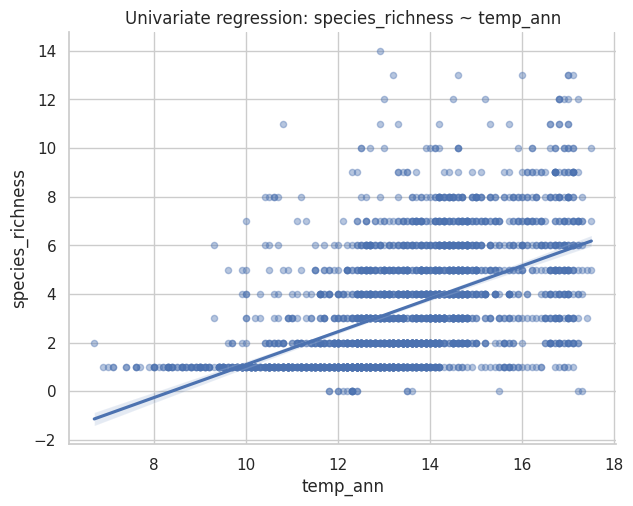

In [ ]:
sns.lmplot(
    data=df_reg,
    x="temp_ann",
    y="species_richness",
    height=5,
    aspect=1.3,
    scatter_kws={"alpha": 0.4, "s": 20}
)
plt.title("Univariate regression: species_richness ~ temp_ann")
plt.show()



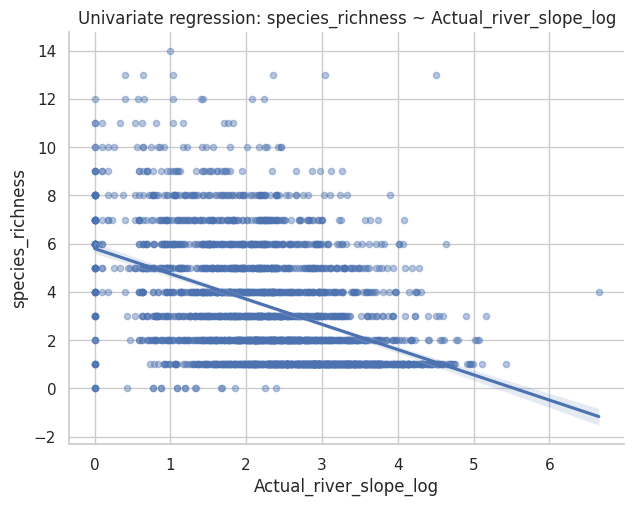

In [ ]:
sns.lmplot(
    data=df_reg,
    x="Actual_river_slope_log",
    y="species_richness",
    height=5,
    aspect=1.3,
    scatter_kws={"alpha": 0.4, "s": 20}
)
plt.title("Univariate regression: species_richness ~ Actual_river_slope_log")
plt.show()

In [ ]:
multi_predictors = list(reg_map.values())  # already transformed/selected

formula_multi = "species_richness ~ " + " + ".join(multi_predictors)
multi_model = smf.ols(formula_multi, data=df_reg).fit()
print(multi_model.summary())

                            OLS Regression Results                            
Dep. Variable:       species_richness   R-squared:                       0.435
Model:                            OLS   Adj. R-squared:                  0.434
Method:                 Least Squares   F-statistic:                     309.7
Date:                Thu, 14 May 2026   Prob (F-statistic):               0.00
Time:                        23:11:58   Log-Likelihood:                -5706.9
No. Observations:                2822   AIC:                         1.143e+04
Df Residuals:                    2814   BIC:                         1.148e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -7

In [ ]:
coef_multi = multi_model.params.drop("Intercept")
coef_multi = coef_multi.rename("beta_multi").to_frame().reset_index()
coef_multi.rename(columns={"index": "regressor_used"}, inplace=True)

comp_df = uni_df.merge(coef_multi, on="regressor_used", how="left")
comp_df

,original_var,regressor_used,beta,R2,F,F_pvalue,beta_multi
0,Altitude,Altitude_log,-0.760290,0.158827,532.461246,4.611434e-108,-0.692639
1,Actual_river_slope,Actual_river_slope_log,-1.046516,0.191888,669.614408,1.173973e-132,-0.462213
2,prec_ann_catch,prec_ann_catch_log,-2.740383,0.085243,262.785610,1.415693e-56,0.598080
3,Elevation_mean_catch,Elevation_mean_catch,-0.001976,0.090947,282.129733,2.025638e-60,-0.000041
4,temp_ann,temp_ann,0.677548,0.282561,1110.645845,1.282194e-205,0.369026
5,temp_jan,temp_jan,0.355283,0.127068,410.493647,2.545736e-85,-0.445406
6,temp_jul,temp_jul,0.695711,0.333688,1412.250441,6.315777e-251,0.475015


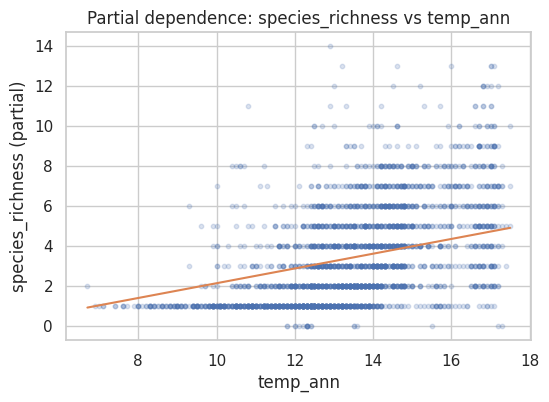

In [ ]:
import numpy as np
import statsmodels.api as sm

def plot_partial_dependence_lin(model, df, var, predictors, n_points=50):
    # grid of the focal variable
    x_grid = np.linspace(df[var].min(), df[var].max(), n_points)

    # baseline: all predictors at their mean
    base = df[predictors].mean().to_frame().T
    base = pd.concat([base]*n_points, ignore_index=True)
    base[var] = x_grid

    # build dataframe with response prediction
    X = sm.add_constant(base)
    y_pred = model.predict(X)

    plt.figure(figsize=(6, 4))
    plt.plot(x_grid, y_pred, color="C1")
    plt.scatter(df[var], df["species_richness"], alpha=0.2, s=10, color="C0")
    plt.xlabel(var)
    plt.ylabel("species_richness (partial)")
    plt.title(f"Partial dependence: species_richness vs {var}")
    plt.show()

# Example for temp_ann
plot_partial_dependence_lin(
    multi_model,
    df_reg,
    var="temp_ann",
    predictors=multi_predictors
)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = df_reg[multi_predictors].copy()
X_const = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["feature"] = X_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_const.values, i)
    for i in range(X_const.shape[1])
]
vif_data

,feature,VIF
0,const,1908.101719
1,Altitude_log,2.994933
2,Actual_river_slope_log,1.368121
3,prec_ann_catch_log,1.556934
4,Elevation_mean_catch,5.539441
5,temp_ann,46.481032
6,temp_jan,26.870854
7,temp_jul,13.057770


In [ ]:
parsimonious_predictors = [
    "Altitude_log",
    "Actual_river_slope_log",
    "prec_ann_catch_log",
    "temp_ann"
]

In [ ]:
formula_pars = "species_richness ~ " + " + ".join(parsimonious_predictors)
pars_model = smf.ols(formula_pars, data=df_reg).fit()
print(pars_model.summary())

                            OLS Regression Results                            
Dep. Variable:       species_richness   R-squared:                       0.336
Model:                            OLS   Adj. R-squared:                  0.336
Method:                 Least Squares   F-statistic:                     357.1
Date:                Thu, 14 May 2026   Prob (F-statistic):          6.19e-249
Time:                        23:13:09   Log-Likelihood:                -5934.1
No. Observations:                2822   AIC:                         1.188e+04
Df Residuals:                    2817   BIC:                         1.191e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  6

In [ ]:
X2 = df_reg[parsimonious_predictors].copy()
X2_const = sm.add_constant(X2)
vif_data2 = pd.DataFrame({
    "feature": X2_const.columns,
    "VIF": [variance_inflation_factor(X2_const.values, i)
            for i in range(X2_const.shape[1])]
})
vif_data2

In [ ]:
# Re-defining parsimonious_predictors and pars_model as they were not defined in the current session state.
parsimonious_predictors = [
    "Altitude_log",
    "Actual_river_slope_log",
    "prec_ann_catch_log",
    "temp_ann"
]
formula_pars = "species_richness ~ " + " + ".join(parsimonious_predictors)
pars_model = smf.ols(formula_pars, data=df_reg).fit()

coef_pars = pars_model.params.drop("Intercept").rename("beta_pars").to_frame()
coef_all = multi_model.params.drop("Intercept").rename("beta_multi").to_frame()

coef_compare = coef_all.join(coef_pars, how="outer")
coef_compare

,beta_multi,beta_pars
Actual_river_slope_log,-0.462213,-0.510198
Altitude_log,-0.692639,-0.135520
Elevation_mean_catch,-0.000041,NaN
prec_ann_catch_log,0.598080,-1.055014
temp_ann,0.369026,0.435855
temp_jan,-0.445406,NaN
temp_jul,0.475015,NaN
